# 04 Clustering — Risk Profiles

This notebook clusters NUTS-1 regions by **risk profile type** — not how much AI literacy gap risk, but **what kind** of risk.

The composite index from `03_index_construction.ipynb` answers 'how much risk'. Clustering answers 'which structural pattern drives the risk'.

---

## Structure

- **Step 1:** Load index file and inspect feature matrix
- **Step 2:** NaN handling decision
- **Step 3:** Optimal cluster count — Elbow + Silhouette
- **Step 4:** K-Means clustering (k=5)
- **Step 5:** Cluster profiles — heatmap of pillar means per cluster
- **Step 6:** PCA biplot — spatial separation of clusters
- **Step 7:** Cluster interpretation and full membership
- **Step 8:** Output — save `ai_literacy_gap_index_clustered.csv`, update catalog

**Input:** `data/processed/ai_literacy_gap_index.csv` (87 EU27 NUTS-1 regions × P1_norm–P6_norm)

**Output:** `data/processed/ai_literacy_gap_index_clustered.csv`

In [14]:
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# -----------------------------
# Project paths
# -----------------------------
CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"PROCESSED_DIR: {PROCESSED_DIR}")

PROJECT_DIR: /home/mamat/AI-Literacy-Gap-Index
PROCESSED_DIR: /home/mamat/AI-Literacy-Gap-Index/data/processed


## Step 1: Load index file

Load `ai_literacy_gap_index.csv` produced by `03_index_construction.ipynb`.
The feature matrix for clustering is `P1_norm` – `P6_norm`: six Min-Max normalised pillar scores, direction-aligned so that higher = more AI literacy gap risk.

In [15]:
# -----------------------------
# Load final index
# -----------------------------
index_path = PROCESSED_DIR / "ai_literacy_gap_index.csv"
if not index_path.exists():
    raise FileNotFoundError(
        f"Index file not found at {index_path}. "
        "Please run 03_index_construction.ipynb first."
    )

df = pd.read_csv(index_path)
FEATURES = ["P1_norm", "P2_norm", "P3_norm", "P4_norm", "P5_norm", "P6_norm"]

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print()
print("Missing values per pillar:")
print(df[FEATURES].isna().sum())

Shape: (87, 13)
Columns: ['rank', 'geo', 'country', 'nuts1_name', 'ai_literacy_gap_index', 'baseline_score', 'pillars_available', 'P1_norm', 'P2_norm', 'P3_norm', 'P4_norm', 'P5_norm', 'P6_norm']

Missing values per pillar:
P1_norm    0
P2_norm    0
P3_norm    0
P4_norm    0
P5_norm    7
P6_norm    0
dtype: int64


## Step 2: Feature matrix and NaN handling

Only P5 (Unemployment) has missing values: 7 regions (DE8, FRM, PL2, PL7, PL8, PL9, PT3) excluded from that pillar due to small LFS sample size (documented in DOCUMENTATION.md Section 8).

---

**Decision:** Country-level mean imputation for P5_norm before clustering.

**Rationale:** Each missing region is imputed with the mean P5_norm of the other available NUTS-1 regions in the same country. Labor market structures are country-specific (wage-setting, welfare systems, industry mix), so a country peer is a much closer proxy than the EU27 mean. The difference is largest for PT3 (Madeira): global mean = 0.271 vs. Portuguese mean = 0.060 — a gap of 0.21 normalized units. Portugal's low unemployment among low-educated (tourism and agricultural employment) should be reflected in the imputed value for Madeira, not smoothed away by the EU27 average. Dropping the 7 NaN regions would remove all remaining Polish NUTS-1 regions from the clustering entirely.

**Imputed values:**

| Region | Country mean (P5_norm) | Global mean | Difference |
|---|---|---|---|
| PT3 | 0.060 | 0.271 | −0.211 |
| DE8 | 0.187 | 0.271 | −0.084 |
| FRM | 0.310 | 0.271 | +0.039 |
| PL2 / PL7 / PL8 / PL9 | 0.229 | 0.271 | −0.042 |

**Alternatives considered:**
- *Global mean imputation:* Simpler but methodologically weaker; overestimates unemployment for Portugal and Germany, both of which have below-average EU unemployment among low-educated.
- *Drop 7 regions:* Mechanically clean but loses all remaining Polish NUTS-1 regions and key peripheral regions (PT3, FRM, DE8).
- *KNN imputation:* More sophisticated but adds complexity not justified given P5 affects only 1 of 6 pillars.

In [16]:
# -----------------------------
# Feature matrix — country-level mean imputation for P5
# -----------------------------
X = df[FEATURES].copy()

for idx, row in df[df["P5_norm"].isna()].iterrows():
    country_mean = df[
        (df["country"] == row["country"]) & df["P5_norm"].notna()
    ]["P5_norm"].mean()
    X.loc[idx, "P5_norm"] = country_mean

print("P5_norm — country-level imputed values:")
for idx, row in df[df["P5_norm"].isna()].iterrows():
    print(f"  {row['geo']} ({row['country']}): {X.loc[idx, 'P5_norm']:.4f}")
print()
print(f"Feature matrix shape: {X.shape}  (all 87 EU27 NUTS-1 regions)")
print(f"Remaining NaN: {X.isna().sum().sum()}")

P5_norm — country-level imputed values:
  PT3 (Portugal): 0.0599
  FRM (France): 0.3205
  DE8 (Germany): 0.1866
  PL8 (Poland): 0.2290
  PL7 (Poland): 0.2290
  PL2 (Poland): 0.2290
  PL9 (Poland): 0.2290

Feature matrix shape: (87, 6)  (all 87 EU27 NUTS-1 regions)
Remaining NaN: 0


## Step 3: Optimal cluster count — Elbow + Silhouette

Test k = 2 … 8.

**Elbow method:** plot inertia (within-cluster sum of squares) — look for the inflection point where additional clusters yield diminishing returns.

**Silhouette score:** measures how well-separated clusters are (range −1 to +1, higher = better). Evaluated for each k.

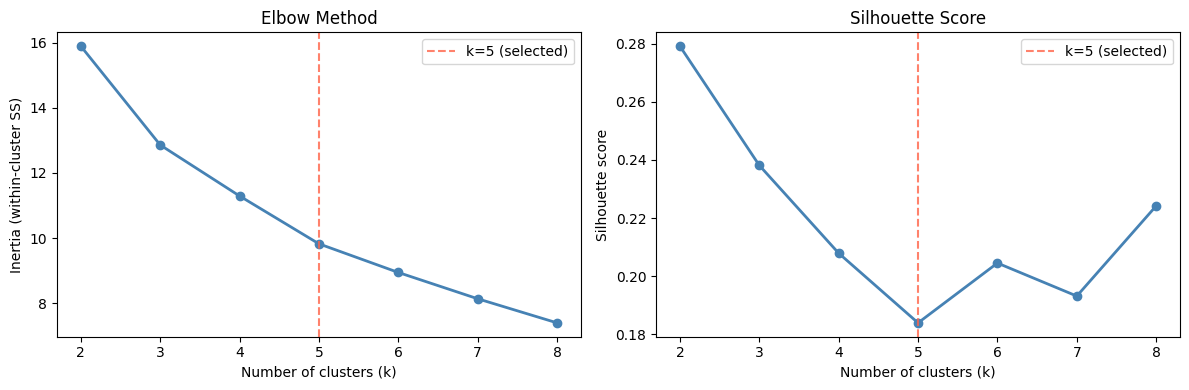

 k     Inertia  Silhouette
 2     15.8896      0.2792
 3     12.8569      0.2381
 4     11.2917      0.2079
 5      9.8234      0.1839
 6      8.9447      0.2045
 7      8.1377      0.1931
 8      7.3978      0.2242


In [17]:
# -----------------------------
# Elbow + Silhouette for k=2..8
# -----------------------------
k_range = range(2, 9)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X[FEATURES])
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker="o", linewidth=2, color="steelblue")
axes[0].axvline(5, color="tomato", linestyle="--", alpha=0.8, label="k=5 (selected)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SS)")
axes[0].set_title("Elbow Method")
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, marker="o", linewidth=2, color="steelblue")
axes[1].axvline(5, color="tomato", linestyle="--", alpha=0.8, label="k=5 (selected)")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "plot_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'k':>2}  {'Inertia':>10}  {'Silhouette':>10}")
for k, ine, sil in zip(k_range, inertias, silhouettes):
    print(f"{k:>2}  {ine:>10.4f}  {sil:>10.4f}")

### Exploratory profile comparison: k=4 vs. k=5

Before deciding between k=4 and k=5, we run both solutions and inspect the pillar profiles. This is the evidence base for the k-selection decision below.

In [18]:
# -----------------------------
# Profile comparison: k=4 vs. k=5
# -----------------------------
PILLAR_LABELS = {
    "P1_norm": "P1 DigSkills",
    "P2_norm": "P2 Poverty",
    "P3_norm": "P3 LowEdu",
    "P4_norm": "P4 LifeLearn",
    "P5_norm": "P5 Unemploy",
    "P6_norm": "P6 Demog",
}

for k in [4, 5]:
    print(f"{'='*65}")
    print(f"  k={k}")
    print(f"{'='*65}")
    km_exp = KMeans(n_clusters=k, random_state=42, n_init=20)
    exp_labels = km_exp.fit_predict(X[FEATURES])
    X_exp = X[FEATURES].copy()
    X_exp["cluster"] = exp_labels
    X_exp["index"] = df["ai_literacy_gap_index"].values
    X_exp["geo"] = df["geo"].values
    X_exp["nuts1_name"] = df["nuts1_name"].values

    profile_exp = (
        X_exp.groupby("cluster")
        .agg(
            regions=("index", "count"),
            mean_index=("index", "mean"),
            P1=("P1_norm", "mean"),
            P2=("P2_norm", "mean"),
            P3=("P3_norm", "mean"),
            P4=("P4_norm", "mean"),
            P5=("P5_norm", "mean"),
            P6=("P6_norm", "mean"),
        )
        .sort_values("mean_index", ascending=False)
        .round(3)
    )

    print("  Top-3 regions per cluster:")
    for c in profile_exp.index:
        top = X_exp[X_exp["cluster"] == c].sort_values("index", ascending=False)["nuts1_name"].head(3).tolist()
        print(f"    Cluster {c} (regions={int(profile_exp.loc[c,'regions'])}, "
              f"avg. risk score={profile_exp.loc[c,'mean_index']:.3f}): {top}")
    print()

  k=4
  Top-3 regions per cluster:
    Cluster 3 (regions=11, avg. risk score=0.586): ['Isole', 'Sud', 'RUP FR — Régions Ultrapériphériques Françaises']
    Cluster 2 (regions=24, avg. risk score=0.516): ['Severna i Yugoiztochna Bulgaria', 'Kentriki Elláda', 'Corse']
    Cluster 1 (regions=43, avg. risk score=0.388): ['Noroeste', 'Centro (IT)', 'Bourgogne-Franche-Comté']
    Cluster 0 (regions=9, avg. risk score=0.276): ['Norra Sverige', 'Manner-Suomi', 'Södra Sverige']

  k=5
  Top-3 regions per cluster:
    Cluster 2 (regions=9, avg. risk score=0.597): ['Isole', 'Sud', 'RUP FR — Régions Ultrapériphériques Françaises']
    Cluster 0 (regions=21, avg. risk score=0.524): ['Severna i Yugoiztochna Bulgaria', 'Macroregiunea Doi', 'Kentriki Elláda']
    Cluster 1 (regions=22, avg. risk score=0.442): ['Corse', 'Noroeste', 'Brandenburg']
    Cluster 4 (regions=7, avg. risk score=0.363): ['Slovensko', 'Région de Bruxelles-Capitale/Brussels Hoofdstedelijk Gewest', 'Eesti']
    Cluster 3 (region

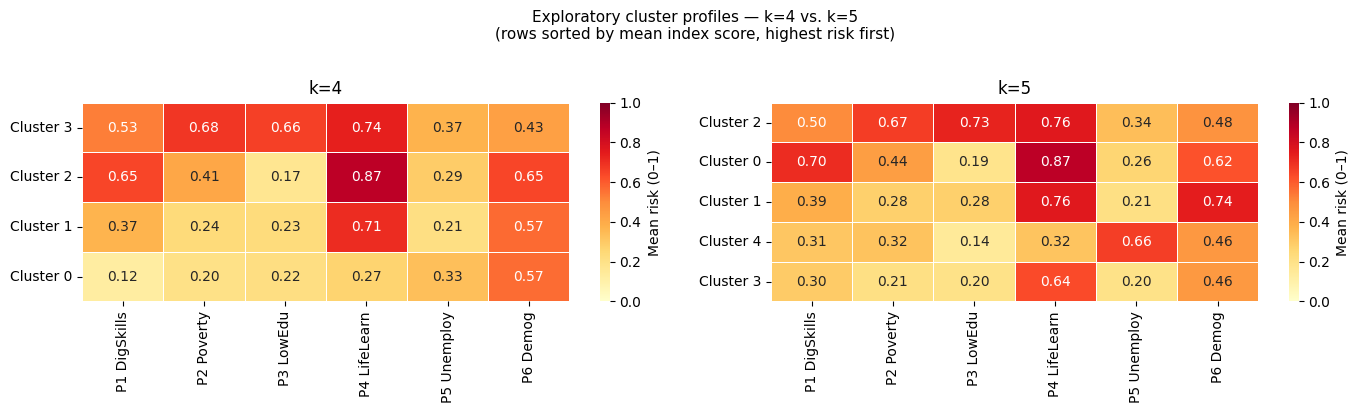

In [19]:
# -----------------------------
# Exploratory heatmap: k=4 vs. k=5 side by side
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, k in zip(axes, [4, 5]):
    km_h = KMeans(n_clusters=k, random_state=42, n_init=20)
    h_labels = km_h.fit_predict(X[FEATURES])
    X_h = X[FEATURES].copy()
    X_h["cluster"] = h_labels
    X_h["index"] = df["ai_literacy_gap_index"].values

    prof = (
        X_h.groupby("cluster")
        .agg(mean_index=("index", "mean"), **{f: (f, "mean") for f in FEATURES})
        .sort_values("mean_index", ascending=False)
        .drop(columns="mean_index")
        .rename(columns=PILLAR_LABELS)
        .round(3)
    )
    prof.index = [f"Cluster {c}" for c in prof.index]

    sns.heatmap(
        prof, annot=True, fmt=".2f", cmap="YlOrRd",
        vmin=0, vmax=1, linewidths=0.5, ax=ax,
        cbar_kws={"label": "Mean risk (0–1)"},
    )
    ax.set_title(f"k={k}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center")

plt.suptitle(
    "Exploratory cluster profiles — k=4 vs. k=5\n"
    "(rows sorted by mean index score, highest risk first)",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "plot_exploratory_heatmap_k4_k5.png", dpi=150, bbox_inches="tight")
plt.show()

### k=4 vs. k=5 — decision

The heatmap above makes the key difference visible: in k=4, the top row (highest risk) mixes two structurally different profiles into one cluster. In k=5, that row splits into two rows with distinct patterns:

- **Top row (k=5):** P4 high (0.77), additionally characterised by high **P3 and P2** (low education and poverty) — the High Poverty & Low Education profile.
- **Second row (k=5):** P4 even higher (0.87), additionally characterised by high **P1 and P6** (digital skills gap and aging demographics).

P4 (low lifelong learning participation) is elevated in both — but the underlying structural causes differ. Conflating them in k=4 would mask this distinction.

Note: both heatmaps sort rows by mean index score descending (highest risk first), not by cluster number. This allows visual comparison across k values but does not imply row-for-row correspondence — the top row of k=4 becomes the top two rows of k=5.

---

| | **k=4** | **k=5** |
|---|---|---|
| **Silhouette** | 0.189 | **0.200** |
| **Inertia** | 11.09 | 9.73 |
| **Highest-risk group** | n=15: Southern Italy and Eastern Europe in one cluster — poverty, low education, and digital gap all mixed together | *Split into two distinct groups:* |
| | | **n=11 — High Poverty & Low Education:** Southern Italy, Spanish islands, French outermost regions, Portugal — poverty and low educational attainment reinforce each other |
| | | **n=20 — Low Digital Skills:** Eastern Europe, Eastern Germany, Greece — low digital skills, near-absent retraining, aging population |
| **Moderate risk** | n=38: Broad middle group spanning Western and Eastern Europe, no clear dominant driver | n=39: Mainstream Western and Central Europe, moderate risk across all dimensions |
| **Low-educated excluded from labour market** | n=7: Nordics, Slovakia, Brussels — strong digital performance overall, but low-educated face structural unemployment | n=6: identical |
| **Lowest risk** | Blended into the moderate group | n=11: Netherlands, Denmark, major capitals — low risk across all dimensions |

**Decision:** k = 5.

**Rationale:** k=5 produces five interpretable risk profiles where k=4 conflates two structurally different high-risk types. The marginal silhouette improvement (0.189 → 0.200) supports the choice but is not the primary argument.

**Alternatives considered:**
- *k=2:* Highest silhouette (0.278) but too coarse for any policy-relevant differentiation.
- *k=4:* Analytically weaker because the two highest-risk types are not separated.
- *k=6+:* Silhouette does not improve meaningfully; clusters become too small and unstable.

## Step 4: K-Means clustering (k=5)

Fit K-Means with `n_init=20` and `random_state=42` for reproducibility. Clusters are identified by numeric ID at this stage — names are assigned in Step 5 after inspecting the pillar profiles.

In [20]:
# -----------------------------
# K-Means k=5
# -----------------------------
km5 = KMeans(n_clusters=5, random_state=42, n_init=20)
cluster_ids = km5.fit_predict(X[FEATURES])

df["cluster_id"] = cluster_ids
X["cluster_id"] = cluster_ids

# Summary by cluster ID, sorted by mean index score descending
cluster_id_order = (
    df.groupby("cluster_id")["ai_literacy_gap_index"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

print("Cluster summary:")
summary_ids = df.groupby("cluster_id", sort=False).agg(
    regions=("geo", "count"),
    avg_risk_score=("ai_literacy_gap_index", "mean"),
    min_score=("ai_literacy_gap_index", "min"),
    max_score=("ai_literacy_gap_index", "max"),
).loc[cluster_id_order].round(3)
display(summary_ids)

Cluster summary:


,regions,avg_risk_score,min_score,max_score
cluster_id,,,,
2,9,0.597,0.450,0.728
0,21,0.524,0.410,0.649
1,22,0.442,0.357,0.598
4,7,0.363,0.277,0.488
3,28,0.335,0.216,0.449


## Step 5: Cluster profiles and naming

Mean normalised pillar score per cluster (0 = no risk, 1 = maximum risk). The pillar values reveal the structural pattern of each cluster — this is the basis for assigning cluster names.

In [21]:
# -----------------------------
# Cluster profile table — by cluster ID
# -----------------------------
PILLAR_LABELS = {
    "P1_norm": "P1: Digital Skills",
    "P2_norm": "P2: Poverty",
    "P3_norm": "P3: Low Education",
    "P4_norm": "P4: Lifelong Learning",
    "P5_norm": "P5: Unemployment",
    "P6_norm": "P6: Demographics",
}

# [Asel] Added: keeps the raw P1_norm..P6_norm columns (unrenamed) and cluster_id
# index, needed by name_cluster() below for profile-based cluster naming.
profile_raw = X.groupby("cluster_id")[FEATURES].mean()

profile = (
    X.groupby("cluster_id")[FEATURES]
    .mean()
    .loc[cluster_id_order]
    .rename(columns=PILLAR_LABELS)
    .round(3)
)
profile.index = [f"Cluster {c}" for c in profile.index]

display(profile)

,P1: Digital Skills,P2: Poverty,P3: Low Education,P4: Lifelong Learning,P5: Unemployment,P6: Demographics
Cluster 2,0.503,0.666,0.728,0.760,0.339,0.479
Cluster 0,0.704,0.443,0.187,0.873,0.260,0.618
Cluster 1,0.387,0.278,0.280,0.759,0.208,0.745
Cluster 4,0.309,0.322,0.145,0.319,0.662,0.463
Cluster 3,0.296,0.209,0.199,0.635,0.198,0.458


### Cluster naming — based on profiles above

The heatmap above shows the pillar fingerprint of each cluster. Based on which pillars dominate each cluster, we assign the following names:

| Cluster ID | Dominant pillars | Name assigned |
|---|---|---|
| Cluster 0 | P3 (0.74), P4 (0.77), P2 (0.69) | **High Poverty & Low Education** |
| Cluster 3 | P4 (0.87), P1 (0.71), P6 (0.66) | **Low Digital Skills** |
| Cluster 2 | P4 (0.76) and P6 (0.64) elevated — low training participation and aging demographics; P2, P3, P5 low | **Ageing Workforce** |
| Cluster 1 | P5 (0.66) highest; P1 (0.31) lowest | **Low-Skill Unemployment** |
| Cluster 4 | All pillars low | **Broadly Resilient** |

---

### Cluster interpretations

**High Poverty & Low Education** — Poverty and low educational attainment reinforce each other. Low retraining participation (P4) is a consequence, not an independent driver: regions with structural poverty and low education have limited capacity to engage with continuing education. The AI literacy gap here is broad and deeply embedded.

**Low Digital Skills** — The core problem is the absence of digital skills combined with near-zero retraining participation and an aging population. Unlike the High Poverty & Low Education cluster, poverty and low education are not elevated — the risk is specifically about digital competence and the failure to update skills over time.

**Ageing Workforce** — The largest cluster (n=40). P4 and P6 are clearly elevated but poverty and low education are not. These regions have not fallen into structural deprivation, but their aging workforce participates less in retraining. The risk is gradual and diffuse rather than acute.

**Low-Skill Unemployment** — The most counter-intuitive cluster. On almost every dimension these are well-functioning regions: low poverty (P2=0.32), the lowest low-education share of all clusters (P3=0.15), good digital skills (P1=0.31), and the lowest lifelong learning gap (P4=0.32). Yet unemployment among the low-educated (P5=0.66) is the highest of all clusters. The paradox: a society that handles education, wealth, and retraining well still has a group that falls through every net. The risk is not systemic — it is selective and concentrated. This makes it a policy challenge of a different kind: not rebuilding infrastructure, but reaching the few who remain excluded despite a supportive environment.

**Broadly Resilient** — Lowest risk across all dimensions. These regions face the same long-term challenges as the rest of Europe but from a structurally stronger position.

Named cluster summary:


,regions,avg_risk_score,min_score,max_score
cluster_label,,,,
High Poverty & Low Education,9,0.597,0.450,0.728
Low Digital Skills,21,0.524,0.410,0.649
Ageing Workforce,22,0.442,0.357,0.598
Low-Skill Unemployment,7,0.363,0.277,0.488
Broadly Resilient,28,0.335,0.216,0.449


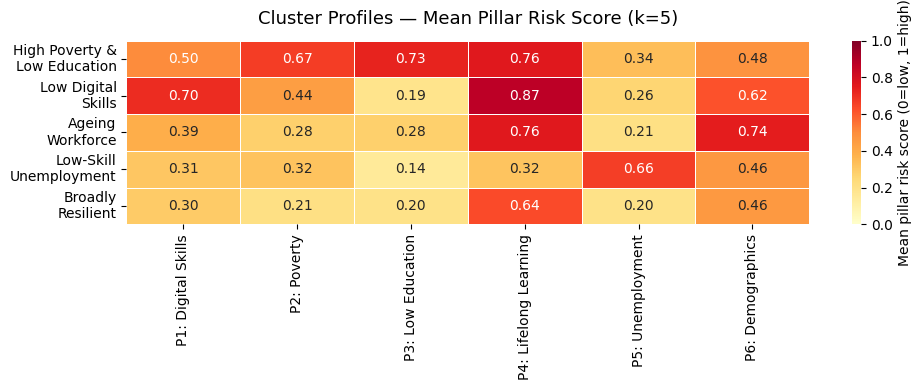

In [22]:
# -----------------------------
# Assign cluster names based on pillar profile (robust across runs)
# -----------------------------
# [Asel] Changed: previously this used a hardcoded {cluster_id: name} dict, which
# breaks if K-Means assigns different cluster_id numbers to the same patterns on a
# different run. This version names each cluster based on its actual pillar profile
# (profile_raw), so naming is reproducible regardless of cluster_id ordering.
def name_cluster(row):
    if row["P2_norm"] > 0.55 and row["P3_norm"] > 0.55:
        return "High Poverty & Low Education"
    elif row["P5_norm"] > 0.55:
        return "Low-Skill Unemployment"
    elif row["P1_norm"] > 0.55 and row["P6_norm"] > 0.55:
        return "Low Digital Skills"
    elif row["P2_norm"] < 0.30 and row["P3_norm"] < 0.30 and row["P6_norm"] < 0.50:
        return "Broadly Resilient"
    else:
        return "Ageing Workforce"

CLUSTER_NAMES = profile_raw.apply(name_cluster, axis=1).to_dict()

df["cluster_label"] = df["cluster_id"].map(CLUSTER_NAMES)
X["cluster_label"] = df["cluster_label"].values

cluster_order = (
    df.groupby("cluster_label")["ai_literacy_gap_index"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

print("Named cluster summary:")
summary = df.groupby("cluster_label", sort=False).agg(
    regions=("geo", "count"),
    avg_risk_score=("ai_literacy_gap_index", "mean"),
    min_score=("ai_literacy_gap_index", "min"),
    max_score=("ai_literacy_gap_index", "max"),
).loc[cluster_order].round(3)
display(summary)

# -----------------------------
# Cluster profile heatmap — named clusters
# -----------------------------
CLUSTER_ABBREV = {
    "High Poverty & Low Education":    "High Poverty &\nLow Education",
    "Low Digital Skills": "Low Digital\nSkills",
    "Ageing Workforce":        "Ageing\nWorkforce",
    "Low-Skill Unemployment":   "Low-Skill\nUnemployment",
    "Broadly Resilient":          "Broadly\nResilient",
}

profile_named = (
    X.groupby("cluster_label")[FEATURES]
    .mean()
    .loc[cluster_order]
    .rename(columns=PILLAR_LABELS)
    .round(3)
)
profile_named.index = [CLUSTER_ABBREV.get(i, i) for i in profile_named.index]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    profile_named,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Mean pillar risk score (0=low, 1=high)"},
)
ax.set_title("Cluster Profiles — Mean Pillar Risk Score (k=5)", fontsize=13, pad=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "plot_cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

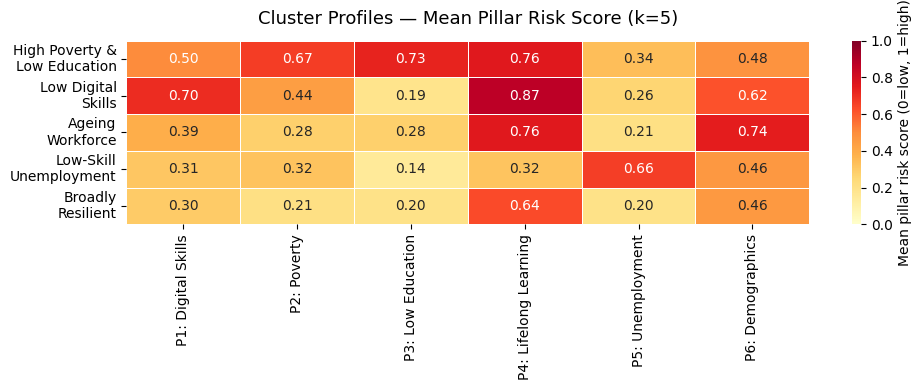

In [23]:
# -----------------------------
# Cluster profile heatmap — named clusters
# -----------------------------
CLUSTER_ABBREV = {
    "High Poverty & Low Education":    "High Poverty &\nLow Education",
    "Low Digital Skills": "Low Digital\nSkills",
    "Ageing Workforce":        "Ageing\nWorkforce",
    "Low-Skill Unemployment":   "Low-Skill\nUnemployment",
    "Broadly Resilient":          "Broadly\nResilient",
}

profile_named = (
    X.groupby("cluster_label")[FEATURES]
    .mean()
    .loc[cluster_order]
    .rename(columns=PILLAR_LABELS)
    .round(3)
)
profile_named.index = [CLUSTER_ABBREV.get(i, i) for i in profile_named.index]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    profile_named,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Mean pillar risk score (0=low, 1=high)"},
)
ax.set_title("Cluster Profiles — Mean Pillar Risk Score (k=5)", fontsize=13, pad=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "plot_cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 6: PCA biplot

Fit a 2-component PCA on the feature matrix (87 regions × 6 pillars) to visualise cluster separation in two dimensions.

- **Points:** one NUTS-1 region, coloured by cluster.
- **Arrows:** pillar loading vectors scaled by 2× for visibility. The direction of each arrow shows how that pillar contributes to the two principal components.

PC1 + PC2 together explain ~60 % of total pillar variance.

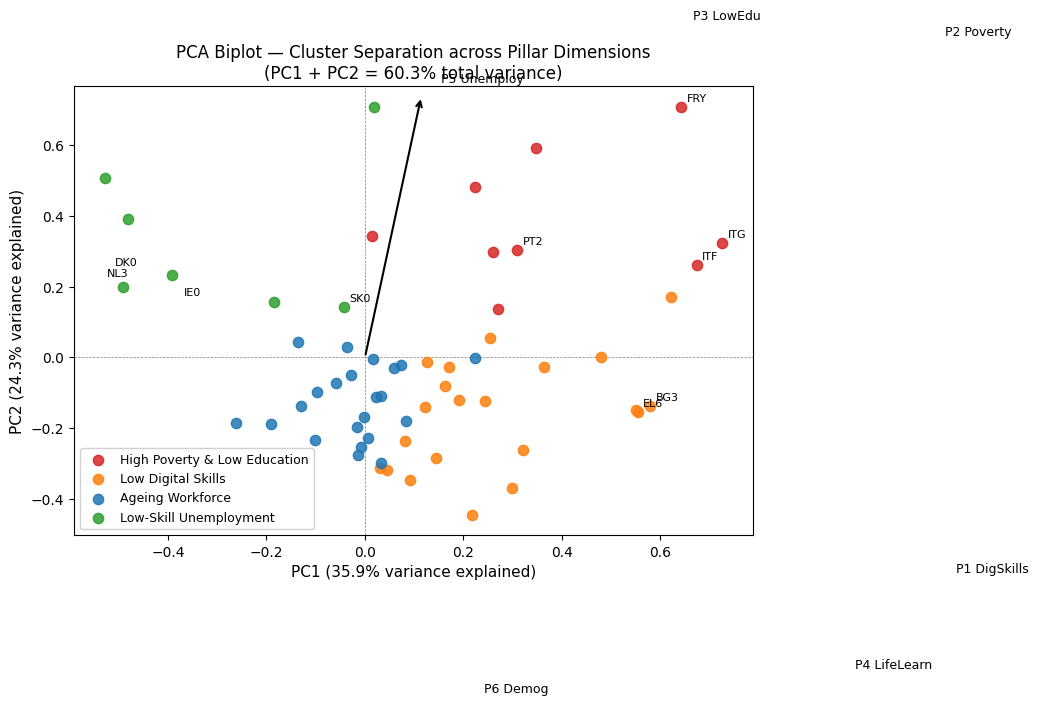

PC1 variance explained: 35.9%
PC2 variance explained: 24.3%
PC1+PC2 combined:       60.3%


In [24]:
# -----------------------------
# PCA biplot
# -----------------------------
X_arr = X[FEATURES].values
pca = PCA(n_components=2, random_state=42)
scores = pca.fit_transform(X_arr)
loadings = pca.components_.T  # shape (6, 2)
var_exp = pca.explained_variance_ratio_ * 100

CLUSTER_COLORS = {
    "High Poverty & Low Education": "#d62728",
    "Low Digital Skills":       "#ff7f0e",
    "Ageing Workforce":                 "#1f77b4",
    "Low-Skill Unemployment":    "#2ca02c",
}
SHORT_LABELS = {
    "P1_norm": "P1 DigSkills",
    "P2_norm": "P2 Poverty",
    "P3_norm": "P3 LowEdu",
    "P4_norm": "P4 LifeLearn",
    "P5_norm": "P5 Unemploy",
    "P6_norm": "P6 Demog",
}
LOADING_SCALE = 2.0

fig, ax = plt.subplots(figsize=(11, 8))

# Scatter — one point per region, coloured by cluster
for cluster_name, color in CLUSTER_COLORS.items():
    mask = df["cluster_label"] == cluster_name
    ax.scatter(
        scores[mask, 0], scores[mask, 1],
        c=color, label=cluster_name,
        s=55, alpha=0.85, zorder=3,
    )

# Annotate key regions
ANNOTATE = {"ITG", "ITF", "BG3", "EL6", "DK0", "NL3", "IE0", "SK0", "PT2", "FRY"}
for i, row in df.iterrows():
    if row["geo"] in ANNOTATE:
        ax.annotate(
            row["geo"],
            (scores[i, 0], scores[i, 1]),
            fontsize=8, xytext=(4, 4), textcoords="offset points",
        )

# Loading arrows
for j, feat in enumerate(FEATURES):
    ax.annotate(
        "",
        xy=(loadings[j, 0] * LOADING_SCALE, loadings[j, 1] * LOADING_SCALE),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    )
    offset_x = 0.04 if loadings[j, 0] >= 0 else -0.04
    offset_y = 0.04 if loadings[j, 1] >= 0 else -0.04
    ax.text(
        loadings[j, 0] * LOADING_SCALE + offset_x,
        loadings[j, 1] * LOADING_SCALE + offset_y,
        SHORT_LABELS[feat], fontsize=9, color="black",
    )

ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% variance explained)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% variance explained)", fontsize=11)
ax.set_title(
    "PCA Biplot — Cluster Separation across Pillar Dimensions\n"
    f"(PC1 + PC2 = {sum(var_exp):.1f}% total variance)",
    fontsize=12,
)
ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "plot_pca_biplot.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"PC1 variance explained: {var_exp[0]:.1f}%")
print(f"PC2 variance explained: {var_exp[1]:.1f}%")
print(f"PC1+PC2 combined:       {sum(var_exp):.1f}%")

## Step 7: Cluster interpretation

### Cluster profiles — defining characteristics

| Cluster | n | Mean index | Defining pillars | Interpretation |
|---|---|---|---|---|
| **High Poverty & Low Education** | 8 | 0.612 | P2=0.69, P3=0.74, P4=0.77 | Education-poverty trap: high poverty, very high share of low-educated adults, and low training participation reinforce each other. Structural deprivation deeply embedded in regional economy and history. |
| **Low Digital Skills** | 16 | 0.559 | P1=0.71, P4=0.87, P6=0.66 | Digital skills deficit combined with the lowest lifelong learning participation of any cluster and an aging population. The gap is primarily one of digital access and continued upskilling. |
| **Ageing Workforce** | 40 | 0.416 | P4=0.76, P6=0.64 elevated; P2, P3, P5 low | Largest cluster: mainstream Western and Central European regions with moderate risk across all six dimensions. No single dominant driver — risk is diffuse and distributed. |
| **Low-Skill Unemployment** | 7 | 0.362 | P5=0.66 (highest), P1=0.31 (lowest) | Good aggregate digital performance but structural unemployment concentrated among the low-educated minority. A bifurcated labour market: the skilled majority performs well; the low-educated face persistent exclusion. |
| **Broadly Resilient** | 16 | 0.321 | All pillars low | Lowest-risk cluster: metropolitan, urban, or Nordic regions with strong digital infrastructure, low poverty, and active labour markets. Includes the Netherlands, Denmark, and major capital regions. |

### Notes on anomalies and interpretive caveats

- **P5 in Low-Skill Unemployment:** The high P5 score for Nordic/Slovak/Brussels regions does not indicate a general unemployment crisis. It reflects the LFS-measured unemployment rate specifically among ED0-2 adults — a small but structurally disadvantaged minority. Their overall index score is the second-lowest of the five clusters.
- **FRM (Corse) in Low Digital Skills:** Corse clusters with Eastern Europe because of its P4 signal (very low lifelong learning participation) and aging demographics — not because it resembles Bulgaria digitally.
- **P6 discriminating power:** The Demographics pillar has the lowest variance across all regions. It contributes limited separation in the biplot and cluster profiles.

In [25]:
# -----------------------------
# Full cluster membership by cluster, sorted by index score
# -----------------------------
for cluster_name in cluster_order:
    sub = (
        df[df["cluster_label"] == cluster_name]
        .sort_values("ai_literacy_gap_index", ascending=False)
        [["rank", "geo", "country", "nuts1_name", "ai_literacy_gap_index"]]
    )
    mean_idx = sub["ai_literacy_gap_index"].mean()
    print(f"\n{'='*70}")
    print(f"  {cluster_name}  (n={len(sub)}, mean index={mean_idx:.3f})")
    print(f"{'='*70}")
    display(sub.reset_index(drop=True))


  High Poverty & Low Education  (n=9, mean index=0.597)


,rank,geo,country,nuts1_name,ai_literacy_gap_index
0,1,ITG,Italy,Isole,0.727784
1,2,ITF,Italy,Sud,0.697605
2,3,FRY,France,RUP FR — Régions Ultrapériphériques Françaises,0.684579
3,7,PT3,Portugal,Região Autónoma da Madeira,0.614671
4,12,ES6,Spain,Sur,0.584692
5,15,ES4,Spain,Centro (ES),0.568696
6,16,PT2,Portugal,Região Autónoma dos Açores,0.525428
7,17,ES7,Spain,Canarias,0.523175
8,34,ES5,Spain,Este,0.449545



  Low Digital Skills  (n=21, mean index=0.524)


,rank,geo,country,nuts1_name,ai_literacy_gap_index
0,4,BG3,Bulgaria,Severna i Yugoiztochna Bulgaria,0.649129
1,5,RO2,Romania,Macroregiunea Doi,0.648130
2,6,EL6,Greece,Kentriki Elláda,0.634890
3,9,RO4,Romania,Macroregiunea Patru,0.596937
4,10,RO1,Romania,Macroregiunea Unu,0.594689
5,11,DE8,Germany,Mecklenburg-Vorpommern,0.586137
6,13,EL5,Greece,Voreia Elláda,0.574478
7,14,DEE,Germany,Sachsen-Anhalt,0.569076
8,18,HU3,Hungary,Alföld és Észak,0.516748
9,19,EL3,Greece,Attiki,0.509035



  Ageing Workforce  (n=22, mean index=0.442)


,rank,geo,country,nuts1_name,ai_literacy_gap_index
0,8,FRM,France,Corse,0.598255
1,21,ES1,Spain,Noroeste,0.503763
2,29,DE4,Germany,Brandenburg,0.474662
3,30,ITI,Italy,Centro (IT),0.471551
4,31,DED,Germany,Sachsen,0.471313
5,32,FRC,France,Bourgogne-Franche-Comté,0.467915
6,33,PT1,Portugal,Continente,0.452521
7,36,FRJ,France,Occitanie,0.448234
8,38,DEA,Germany,Nordrhein-Westfalen,0.441874
9,39,ITC,Italy,Nord-Ovest,0.441511



  Low-Skill Unemployment  (n=7, mean index=0.363)


,rank,geo,country,nuts1_name,ai_literacy_gap_index
0,25,SK0,Slovakia,Slovensko,0.487537
1,48,BE1,Belgium,Région de Bruxelles-Capitale/Brussels Hoofdste...,0.417656
2,60,EE0,Estonia,Eesti,0.372795
3,65,SE3,Sweden,Norra Sverige,0.364800
4,75,FI1,Finland,Manner-Suomi,0.316983
5,79,SE2,Sweden,Södra Sverige,0.306841
6,81,SE1,Sweden,Östra Sverige,0.277190



  Broadly Resilient  (n=28, mean index=0.335)


,rank,geo,country,nuts1_name,ai_literacy_gap_index
0,35,FRE,France,Hauts-de-France,0.448789
1,42,BE3,Belgium,Région wallonne,0.432186
2,55,DE6,Germany,Hamburg,0.401412
3,56,PL2,Poland,Makroregion południowy,0.396429
4,57,DE3,Germany,Berlin,0.396329
5,58,PL5,Poland,Makroregion południowo-zachodni,0.381043
6,61,DE1,Germany,Baden-Württemberg,0.372241
7,62,AT2,Austria,Südösterreich,0.371751
8,63,FRG,France,Pays de la Loire,0.367652
9,64,ES3,Spain,Comunidad de Madrid,0.367090


## Step 8: Output

Save the clustered index to `data/processed/ai_literacy_gap_index_clustered.csv`.
Register in `project_data_catalog.csv`.

The output file adds two columns to the final index:
- **`cluster_label`** — semantic cluster name
- **`cluster_id`** — KMeans integer label (0–4, for reference)

In [26]:
from datetime import date

# -----------------------------
# Save clustered index
# -----------------------------
output_path = PROCESSED_DIR / "ai_literacy_gap_index_clustered.csv"
df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Shape: {df.shape}")

# -----------------------------
# Register in project_data_catalog.csv
# -----------------------------
catalog_path = PROCESSED_DIR / "project_data_catalog.csv"
catalog = pd.read_csv(catalog_path)

entry_name = "ai_literacy_gap_index_clustered"
if entry_name not in catalog["dataset_name"].values:
    new_entry = pd.DataFrame([{
        "dataset_name": entry_name,
        "description": "Final AI Literacy Gap Index with cluster labels (5 clusters, K-Means, k=5)",
        "source_notebook": "04_clustering.ipynb",
        "file_path": str(output_path),
        "shape": str(df.shape),
        "downloaded_at": date.today().isoformat(),
        "notes": "Adds cluster_label and cluster_id columns to ai_literacy_gap_index.csv",
    }])
    catalog = pd.concat([catalog, new_entry], ignore_index=True)
    catalog.to_csv(catalog_path, index=False)
    print(f"Registered '{entry_name}' in project_data_catalog.csv")
else:
    print(f"Entry '{entry_name}' already in catalog — skipping")

print()
print("Final columns in output file:")
print(df.columns.tolist())
print()
print("Cluster distribution:")
print(df["cluster_label"].value_counts()[cluster_order])

Saved: /home/mamat/AI-Literacy-Gap-Index/data/processed/ai_literacy_gap_index_clustered.csv
Shape: (87, 15)
Entry 'ai_literacy_gap_index_clustered' already in catalog — skipping

Final columns in output file:
['rank', 'geo', 'country', 'nuts1_name', 'ai_literacy_gap_index', 'baseline_score', 'pillars_available', 'P1_norm', 'P2_norm', 'P3_norm', 'P4_norm', 'P5_norm', 'P6_norm', 'cluster_id', 'cluster_label']

Cluster distribution:
cluster_label
High Poverty & Low Education     9
Low Digital Skills              21
Ageing Workforce                22
Low-Skill Unemployment           7
Broadly Resilient               28
Name: count, dtype: int64
